In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# 90 degree difference 
q1= [0.87, 0.36, 0.32, 0.09]
q2= [0.870, -0.361, 0.290, -0.163]

/tmp/ipykernel_668816/2643099681.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


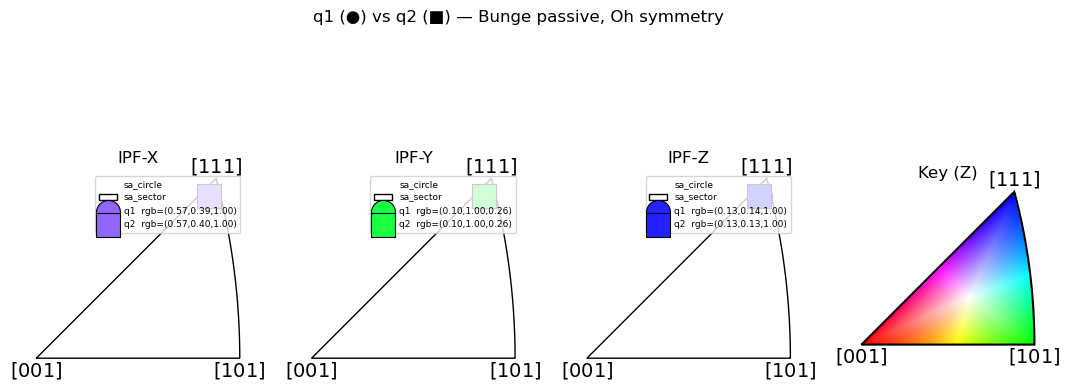

In [19]:

import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.quaternion.symmetry import Oh
from orix import plot as orix_plot
from orix.vector import Vector3d

# orix uses Bunge convention — pass quaternions directly, no conjugation needed
ori = Orientation(np.stack([q1, q2]), symmetry=Oh)

ckey = orix_plot.IPFColorKeyTSL(Oh.laue)
ref_dirs = {"X": Vector3d.xvector(), "Y": Vector3d.yvector(), "Z": Vector3d.zvector()}

# Compute IPF RGB color for each orientation and each reference direction
colors = {}  # ref_dir -> (2, 3) RGB array
for name, vec in ref_dirs.items():
    ckey.direction = vec
    colors[name] = ckey.orientation2color(ori)  # shape (2, 3)

# --- Plot: color swatches + IPF scatter ---
fig = plt.figure(figsize=(13, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.85], wspace=0.3)

for col, name in enumerate(["X", "Y", "Z"]):
    ax = fig.add_subplot(gs[col], projection="ipf", symmetry=Oh.laue)
    ckey.direction = ref_dirs[name]

    # Scatter the two orientations, colored by their IPF color
    for i, (label, marker) in enumerate(zip(["q1", "q2"], ["o", "s"])):
        ax.scatter(
            Orientation(ori[i].data, symmetry=Oh),
            c=[colors[name][i]],
            s=300,
            marker=marker,
            edgecolors="k",
            linewidths=0.8,
            label=f"{label}  rgb=({colors[name][i][0]:.2f},{colors[name][i][1]:.2f},{colors[name][i][2]:.2f})",
            zorder=5,
        )
    ax.set_title(f"IPF-{name}")
    ax.legend(fontsize=6.5, loc="upper right")

# Color key
ax_key = fig.add_subplot(gs[3], projection="ipf", symmetry=Oh.laue)
ckey.direction = Vector3d.zvector()
ax_key.plot_ipf_color_key()
ax_key.set_title("Key (Z)")

plt.suptitle("q1 (●) vs q2 (■) — Bunge passive, Oh symmetry", y=1.01)
plt.tight_layout()
plt.show()


In [20]:

import torch

def misorientation_bunge(q1: torch.Tensor, q2: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """
    Misorientation angle (radians) between two batches of Bunge passive quaternions.
    Both q1, q2: (N, 4) in [w, x, y, z] order, need not be pre-normalised.
    Returns: (N,) tensor of angles in [0, π].

    In Bunge convention the relative rotation is q1⁻¹ ⊗ q2.
    For unit quaternions: w(q1⁻¹ ⊗ q2) = q1 · q2 = cos(θ/2).
    """
    n1 = q1 / q1.norm(dim=-1, keepdim=True).clamp_min(eps)
    n2 = q2 / q2.norm(dim=-1, keepdim=True).clamp_min(eps)
    cos_half = (n1 * n2).sum(dim=-1).abs().clamp(max=1.0)
    return 2.0 * torch.acos(cos_half)


In [21]:

t1 = torch.tensor(q1, dtype=torch.float32).unsqueeze(0)
t2 = torch.tensor(q2, dtype=torch.float32).unsqueeze(0)

angle_rad = misorientation_bunge(t1, t2).item()
angle_deg = angle_rad * 180.0 / torch.pi

print(f"q1 = {q1}")
print(f"q2 = {q2}")
print(f"Misorientation: {angle_rad:.6f} rad  |  {angle_deg:.4f}°")


q1 = [0.87, 0.36, 0.32, 0.09]
q2 = [0.87, -0.361, 0.29, -0.163]
Misorientation: 1.571449 rad  |  90.0374°


In [22]:

import numpy as np
from orix.quaternion import symmetry as SYM

# --- Oh symmetry operators (48 ops, Laue group) in [w,x,y,z] ---
oh_ops_np = np.asarray(SYM.Oh.data, dtype=np.float32)     # (48, 4)
oh_ops     = torch.from_numpy(oh_ops_np)                   # (48, 4)

# Unit-quaternion inverse = conjugate: negate xyz
oh_ops_inv = oh_ops.clone()
oh_ops_inv[:, 1:] *= -1.0                                  # (48, 4)


def quat_mul(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """Hamilton product a ⊗ b, both (...,4) [w,x,y,z]."""
    wa, xa, ya, za = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    wb, xb, yb, zb = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return torch.stack([
        wa*wb - xa*xb - ya*yb - za*zb,
        wa*xb + xa*wb + ya*zb - za*yb,
        wa*yb - xa*zb + ya*wb + za*xb,
        wa*zb + xa*yb - ya*xb + za*wb,
    ], dim=-1)


def reduce_to_fz_oh(q_1x4: torch.Tensor, sym_inv: torch.Tensor) -> torch.Tensor:
    """
    Reduce q to the Oh fundamental zone via left-multiplication: s_inv ⊗ q.
    Returns the equivalent with maximum w (= minimum misorientation from identity).
    """
    G = sym_inv.shape[0]
    cands = quat_mul(sym_inv, q_1x4.expand(G, -1))   # (G, 4): s_inv ⊗ q
    cands = torch.where(cands[:, 0:1] < 0, -cands, cands)   # enforce w >= 0
    return cands[cands[:, 0].argmax()]                        # (4,) best representative


q1_fz = reduce_to_fz_oh(t1, oh_ops_inv)   # (4,)
q2_fz = reduce_to_fz_oh(t2, oh_ops_inv)   # (4,)

print(f"q1     = {[round(v,4) for v in t1[0].tolist()]}")
print(f"q1_fz  = {[round(v,4) for v in q1_fz.tolist()]}")
print()
print(f"q2     = {[round(v,4) for v in t2[0].tolist()]}")
print(f"q2_fz  = {[round(v,4) for v in q2_fz.tolist()]}")
print()
# Misorientation between the two FZ representatives
angle_fz = misorientation_bunge(q1_fz.unsqueeze(0), q2_fz.unsqueeze(0)).item()
print(f"Misorientation (FZ reps): {angle_fz:.6f} rad  |  {angle_fz * 180 / torch.pi:.4f}°")


q1     = [0.87, 0.36, 0.32, 0.09]
q1_fz  = [0.87, 0.36, 0.32, 0.09]

q2     = [0.87, -0.361, 0.29, -0.163]
q2_fz  = [0.8704, 0.3599, 0.3203, 0.0898]

Misorientation (FZ reps): 0.000000 rad  |  0.0000°
